In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = sns.load_dataset('titanic')

df = df[['age', 'fare',  'survived']]

df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [4]:
df.isnull().sum()

age         177
fare          0
survived      0
dtype: int64

In [5]:
X = df[['age', 'fare']]
y = df['survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=2)

In [7]:
X_train.shape, X_test.shape

((712, 2), (179, 2))

In [8]:
X_train['age_imputed'] = X_train['age']
X_test['age_imputed'] = X_test['age']

In [9]:
X_train.head()

,age,fare,age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [10]:
X_train['age_imputed'][X_train['age_imputed'].isnull()] = X_train['age'].dropna().sample(X_train['age'].isnull().sum()).values
X_test['age_imputed'][X_test['age_imputed'].isnull()] = X_test['age'].dropna().sample(X_test['age'].isnull().sum()).values

C:\Users\praja\AppData\Local\Temp\ipykernel_13336\73937911.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['age_imputed'][X_train['age_imputed'].isnull()] = X_train['age'].dropna().sample(X_train['age'].isnull().sum()).values
C:\Users\praja\AppData\Local\Temp\ipykernel_13336\73937911.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series

In [11]:
X_train

,age,fare,age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


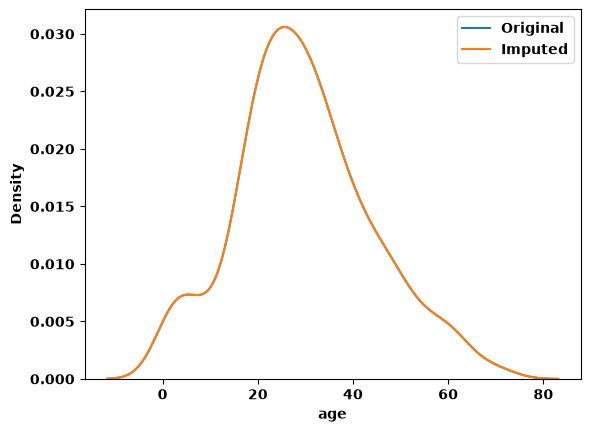

In [13]:
sns.kdeplot(X_train['age'], label='Original')
sns.kdeplot(X_train['age_imputed'], label='Imputed')

plt.legend()
plt.show()